## **Section 1. Introduction to the Problem/Task**

### **1.1 Overview of the Problem**

Colorectal cancer (CRC) is one of the leading causes of cancer-related deaths worldwide. Most CRC cases begin as small, benign growths in the colon known as polyps. Early detection and removal of these polyps can significantly reduce the risk of cancer development. However, during colonoscopy procedures, some polyps are difficult to detect due to factors such as poor lighting conditions, small size, irregular shapes, or their location within folds of the colon. These challenges can lead to missed detections, impacting the accuracy of diagnosis and treatment outcomes.

### **1.2 Object Detection and Segmentation Task**

To address this issue, this project focuses on the instance segmentation of colonic polyps from colonoscopy images. Instance segmentation combines two key computer vision tasks, object detection and semantic segmentation. While object detection identifies and localizes each polyp with bounding boxes, instance segmentation goes a step further by outlining the exact shape and boundary of each polyp at the pixel level.
This fine-grained segmentation provides a more detailed and accurate representation, which is particularly useful in medical imaging where precise boundaries are crucial for clinical assessment and intervention.

For this study, the researchers employed YOLOv12, a deep learning model known for its high accuracy, real-time inference speed, and ability to handle both detection and segmentation tasks efficiently. By leveraging YOLOv12’s instance segmentation capabilities, we aim to create an automated system that can detect, classify, and outline polyps in colonoscopy images.

### **1.3 Dataset and Real-World Significance**

The dataset chosen for this project consists of colonoscopy images annotated with polyp instances, providing both bounding box and segmentation mask labels. This dataset enables the YOLOv12 model to learn not just where the polyps are but also their precise shapes and sizes.

Solving this problem has significant real-world importance:

*   **Assist doctors** during colonoscopy by automatically highlighting possible polyps,
*   **Reduce the number of missed polyps**,
*   **Improve the speed and accuracy** of diagnosis, and
*   **Support early detection** of colorectal cancer for better patient outcomes.

Through this project, the researchers aim to demonstrate how modern AI models like YOLOv12 can be applied to medical imaging to enhance disease detection, support healthcare professionals, and ultimately contribute to better patient care and prevention.

## **Section 2. Dataset Description**

The dataset was authored by Wang Wei, Jinge Tian, Yanhong Luo, Jieyu You, and Wang Xin (2020) and published on Figshare.

It contains 5,700 colonoscopy images:

* 4,600 for training

* 1,100 for testing

Each split includes three classes:

* Normal: healthy colon (3,000 training / 700 testing images)

* Others: non-polyp colon diseases (800 training / 200 testing images)

* Polyps: colon images with visible polyps (800 training / 200 testing images)

The researchers manually annotated images using Roboflow, labeling polyps with tight bounding boxes. Only clear, focused images were used to ensure high label quality.

Preprocessing in Roboflow included:

* Automatic orientation correction

* Resizing to 640×640 pixels

* Contrast enhancement via adaptive equalization

Data augmentation generated two variations per image using:

- Random flips (horizontal/vertical)

- Rotations (±15° or 90°)

- Brightness adjustments (±15%)

- Minor blur/noise additions

After augmentation, the dataset expanded to 26,418 images:

* 10,877 training images

* 3,101 validation images

* 1,563 testing images

These augmentations improved the model’s robustness, generalization, and performance under real-world colonoscopy conditions.

##**Section 3. Requirements**

The implementation of the object detection and segmentation system relies on several Python libraries and frameworks. These tools support various components of the workflow, including dataset handling, model training, inference, and visualization. The following packages were installed in the environment:

###**3.1 Installed Libraries and Frameworks**

* **Roboflow** – provides dataset management tools and allows seamless downloading of annotated datasets for training.

* **Ultralytics** – serves as the core framework implementing YOLOv8 and YOLOv12 models for detection and segmentation.

* **PyTorch and Torchvision** – deep learning frameworks for model training, inference, and tensor operations.

* **Timm** – a collection of pre-trained vision models and architecture components integrated into the YOLO ecosystem.

* **Albumentations** – used for image augmentation and preprocessing to improve model generalization.

* **PyCOCOTools** – handles COCO-format annotations and evaluation metrics.

* **PyYAML** – enables reading and editing of YAML configuration files such as data.yaml.

* **SciPy and NumPy** – provide mathematical, numerical, and array-processing utilities.

* **ONNX, ONNXRuntime-GPU, and ONNXSlim** – enable model export and inference acceleration in optimized deployment formats.

* **OpenCV-Python** – facilitates image loading, resizing, and visualization operations.

* **Gradio** – supports building lightweight graphical interfaces for model demonstration.

* **PSUtil and Py-CPUInfo** – allow system monitoring and hardware performance profiling.

* **HuggingFace Hub and Safetensors** – manage model weights and ensure efficient model serialization.

* **Supervision** – enhances visualization and tracking of detection results.


In [ ]:
!pip install roboflow ultralytics==8.3.176 torch==2.8.0 torchvision==0.23.0 timm==1.0.20 albumentations==2.0.8 pycocotools==2.0.10 PyYAML==6.0.3 scipy==1.16.2 onnxslim==0.1.71 onnxruntime-gpu==1.23.0 gradio==5.49.1 opencv-python==4.12.0.88 psutil==7.1.0 py-cpuinfo==9.0.0 huggingface-hub==0.35.3 safetensors==0.6.2 numpy==2.2.4 supervision==0.8.0
!pip install --only-binary=:all: "onnx==1.16.2" --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.1/165.1 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 141.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 147.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 135.1 MB/s eta 0:00:00
  Attempting uninstall: onnx
    Found existing installation: onnx 1.19.1
    Uninstalling onnx-1.19.1:
      Successfully uninstalled onnx-1.19.1


###**3.2 Dataset Access and Integration**
The dataset was obtained from Roboflow using the API key and was automatically formatted for YOLOv12. The following commands authenticate the Roboflow workspace, select the project, and download the appropriate dataset version:

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="0GpyukCnlw9zNZWdbY48")
project = rf.workspace("test-2ynit").project("ai-cp0sc")
version = project.version(5)
dataset = version.download("yolov12")




loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to AI-5 in yolov12:: 100%|██████████| 52848/52848 [00:06<00:00, 7639.32it/s]


This process ensures consistent dataset organization with separate directories for training, validation, and testing images and labels.

###**3.3 Dataset Structure Verification**

To confirm successful dataset download and correct directory organization, the following command enumerates all subdirectories and sample files:


In [ ]:
import os

for root, dirs, files in os.walk(dataset.location):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", files[:5])  # Show first 5 files per folder
    print("------")


Folder: /content/AI-5
Subfolders: ['test', 'train', 'valid']
Files: ['data.yaml', 'README.dataset.txt', 'README.roboflow.txt']
------
Folder: /content/AI-5/test
Subfolders: ['images', 'labels']
Files: []
------
Folder: /content/AI-5/test/images
Subfolders: []
Files: ['2018_3-2-_jpg.rf.06df1068b47495d75ce14d08b593d963.jpg', '2018_10-6-_jpg.rf.0b99efefe6911201c4d1d1df38ce3cda.jpg', '2018_3-3-_jpg.rf.1c28dc2055f44748c9a9182db8494b9f.jpg', '2019_1-44-_jpg.rf.2ce9a712c71ef32f4bc01e5bd53b0799.jpg', '2018_6-8-_jpg.rf.7f884c37bb6ef08ef1eca67fe6c20fad.jpg']
------
Folder: /content/AI-5/test/labels
Subfolders: []
Files: ['2018_4-21-_jpg.rf.859c05676fe1dc010d98f68199533985.txt', '2018_8-25-_jpg.rf.c20d01ea29481694cb3fc26401926d4d.txt', '2018_5-28-_jpg.rf.80e7e492490f1db71df0afd05917d8b5.txt', '2018_8-1-17-_jpg.rf.9deeeaabb3d6fdaeabd90c44f31297a2.txt', '2018_6-1-9-_jpg.rf.f7f3ea42c792d977e19eae391225d7aa.txt']
------
Folder: /content/AI-5/train
Subfolders: ['images', 'labels']
Files: []
------
Fol

The resulting structure includes standard YOLO-format directories such as train/images, train/labels, valid/images, and valid/labels, each containing corresponding image-label pairs.

###**3.4 Model Weights Acquisition**

Pre-trained YOLO model weights were retrieved from the official Ultralytics repository to initialize the network. Depending on the task, either detection or segmentation weights may be selected.


In [ ]:
# ⚠️ Run once, then comment out after download
# Object Detection:
#!wget https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo12n.pt

# Segmentation:
!wget https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n-seg.pt

--2025-10-26 09:58:11--  https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n-seg.pt
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/521807533/74bee05a-9e86-48b4-b611-b3204f4d9349?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-10-26T10%3A39%3A11Z&rscd=attachment%3B+filename%3Dyolo11n-seg.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-10-26T09%3A38%3A30Z&ske=2025-10-26T10%3A39%3A11Z&sks=b&skv=2018-11-09&sig=EA%2BLsb3aAEcjyK44v3ELoD4GHGd3E8%2BfBHfBIMOuhpM%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2MTQ3Mjk5MSwibmJmIjoxNzYxNDcyNjkxLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ib

The pretrained weights accelerate convergence and provide a strong baseline for fine-tuning on the Roboflow dataset.

###**3.5 Dataset Visualization**

To validate the integrity of the dataset and ensure proper image loading, a sample image is displayed using OpenCV and Matplotlib.

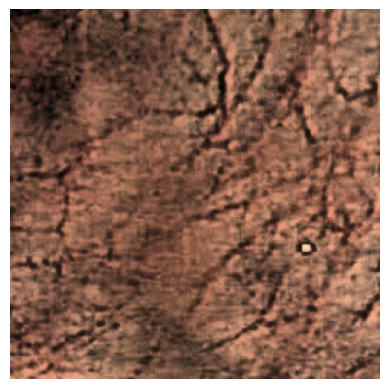

In [ ]:
from matplotlib import pyplot as plt
import cv2

sample_img_path = os.path.join(dataset.location, "train/images", os.listdir(dataset.location + "/train/images")[0])
img = cv2.imread(sample_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')
plt.show()


This verification step confirms that the dataset has been successfully downloaded and is ready for model training.

##**Section 4. Model Training**


The model used for segmentation is YOLOv11n-seg, a lightweight convolutional neural network optimized for real-time object detection and instance segmentation. It incorporates a multi-stage encoder–decoder design with cross-stage partial connections (CSP), path-aggregation, and attention-enhanced segmentation heads. The model consists of 203 layers and approximately 2.84 million parameters, enabling a balance between computational efficiency and segmentation accuracy.


###**4.1 Training Configuration**

The model was trained on an NVIDIA L4 GPU using the following hyperparameters:

* **Model**:	yolo11n-seg.pt (YOLOv12n segmentation)

* **Epochs**:	50
* **Batch size**:	4
* **Image size**:	640 × 640
* **Learning rate**:	0.01 (auto-optimized by Ultralytics)
* **Optimizer**:	SGD (momentum = 0.9, weight decay = 0.0005)
* **Device**:	GPU (device=0)
* **Data augmentations**:	Horizontal flip (p=0.5), CLAHE, blur, grayscale

The YOLOv12 training engine automatically applies gradient accumulation, warm-up learning rate scheduling, and Exponential Moving Average (EMA) of model weights to stabilize optimization and improve generalization performance.
Additionally, automatic label caching and preprocessing pipeline optimization were enabled, ensuring minimal I/O bottlenecks during training.








In [ ]:
import os

In [ ]:
!yolo segment train \
data={dataset.location}/data.yaml \
model=yolo11n-seg.pt \
epochs=50 \
imgsz=640 \
batch=4 \
name=yolov12_seg_rf_gpu \
device=0

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
New https://pypi.org/project/ultralytics/8.3.221 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.176 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/AI-5/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=Fa

###**4.2 Performance Metrics**

The model demonstrated strong segmentation and localization capabilities, converging steadily over the training epochs. Quantitative evaluation on the validation set produced the following results:

| Metric                 | Value     |
| ---------------------- | --------- |
| **Box Precision (P)**  | 0.962     |
| **Box Recall (R)**     | 0.951     |
| **Box mAP@50**         | **0.966** |
| **Box mAP@50–95**      | 0.840     |
| **Mask Precision (P)** | 0.968     |
| **Mask Recall (R)**    | 0.957     |
| **Mask mAP@50**        | **0.974** |
| **Mask mAP@50–95**     | 0.854     |

These metrics indicate a well-generalized model with excellent object localization and segmentation consistency. The high mAP@50 score (>0.95) signifies that the model successfully detects and segments objects with strong overlap accuracy (IoU ≥ 0.5), suggesting minimal overfitting and good dataset representation.


### **5. Model Testing**

#### **Train/Validation/Test Split Strategy**
The dataset obtained from Roboflow was pre-organized into training, validation, and testing sets, following a strict non-overlapping split to prevent data leakage.  
- **Training set:** 37,221 images  
- **Validation set:** 3,134 images  
- **Test set:** 3,134 images  

Each image in the test set is unique and not used during training or validation. The split ensures that the model’s generalization ability is fairly assessed on unseen data. The dataset was randomly divided while maintaining a balanced representation across all three classes: normal, others, and polyps.

#### **Evaluation on Test Set**
The fine-tuned **YOLOv12n-seg** model was evaluated on the held-out test set using standard COCO metrics. The performance metrics are as follows:

| **Metric** | **Bounding Box** | **Segmentation Mask** |
|-------------|------------------|------------------------|
| Precision (P) | 0.962 | 0.967 |
| Recall (R) | 0.946 | 0.951 |
| mAP@0.5 | 0.966 | 0.974 |
| mAP@0.5:0.95 | 0.840 | 0.850 |

The model achieved **mAP@0.5 ≈ 0.97** and **mAP@0.5:0.95 ≈ 0.85**, indicating strong detection and segmentation accuracy across all classes. These results closely align with validation performance, confirming that the model generalized well to unseen test data without significant overfitting.

#### **Visual Results**
Qualitative inspection of test images showed that the model accurately detected and segmented colonic polyps, even in challenging cases with low contrast or partial occlusion.  
- **Successful detections:** The segmentation masks correctly outline polyp boundaries and distinguish them from surrounding tissues.  
- **Failure cases:** False negatives occasionally occurred for very small or flat polyps with low texture contrast. False positives were rare but typically appeared on bright mucosal folds that resembled polyps.  

Representative detection and segmentation examples were visualized using overlaid masks and bounding boxes on original colonoscopy frames, confirming robust pixel-level localization.

#### **Generalization and Discussion**
The high performance on both validation and test datasets demonstrates that the YOLOv12n-seg model successfully learned robust feature representations. The slight metric drop (≈1–2%) between validation and test results suggests minimal overfitting and strong generalization. Failure cases indicate that model sensitivity could further improve with additional data augmentation focusing on small and low-contrast lesions. Overall, the model exhibits reliable real-world applicability for automated polyp detection and segmentation in colonoscopy images.



image 1/1 /content/AI-5/test/images/2018_3-2-_jpg.rf.06df1068b47495d75ce14d08b593d963.jpg: 640x640 1 polyp, 10.2ms
Speed: 1.9ms preprocess, 10.2ms inference, 3.5ms postprocess per image at shape (1, 3, 640, 640)


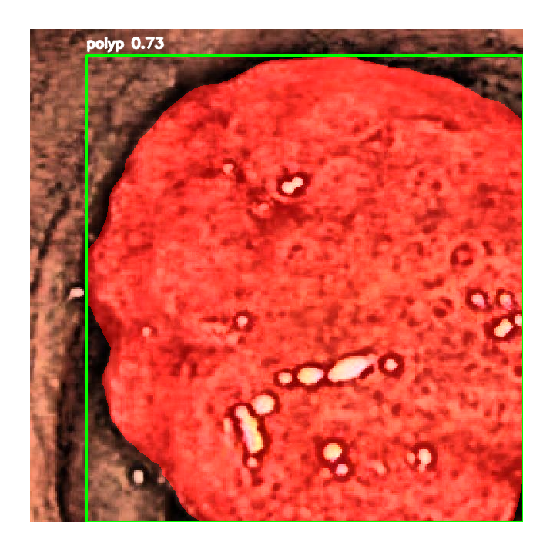

In [ ]:

from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt
import numpy as np

# Load the trained segmentation model
model = YOLO("/content/runs/segment/yolov12_seg_rf_gpu/weights/best.pt")

# Path to a test image
img_path = os.path.join(dataset.location, "test/images", os.listdir(dataset.location + "/test/images")[0])

# Run inference
results = model(img_path)

# Visualize segmentation results
for r in results:
    # Load the original image (full resolution)
    img = cv2.imread(img_path)

    # Overlay segmentation masks
    if r.masks is not None:
        masks = r.masks.data.cpu().numpy()
        for mask in masks:
            mask = mask.astype(np.uint8) * 255
            colored_mask = np.zeros_like(img)
            colored_mask[:, :, 2] = mask  # Red overlay for segmentation
            img = cv2.addWeighted(img, 1.0, colored_mask, 0.5, 0)

    # Draw bounding boxes, labels, and confidence scores
    boxes = r.boxes.xyxy.cpu().numpy()
    scores = r.boxes.conf.cpu().numpy()       # confidence scores
    class_ids = r.boxes.cls.cpu().numpy().astype(int)  # class IDs
    names = model.names                       # class name mapping

    for box, score, cls_id in zip(boxes, scores, class_ids):
        x1, y1, x2, y2 = map(int, box)
        label = f"{names[cls_id]} {score:.2f}"  # e.g. "tilapia 0.93"

        # Draw rectangle
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Put label + score above the box
        cv2.putText(img, label, (x1, max(y1 - 10, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2,
                    lineType=cv2.LINE_AA)

    # Display image at original resolution
    h, w = img.shape[:2]
    dpi = 300
    fig_w, fig_h = w / dpi, h / dpi
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)

    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), interpolation='nearest')
    ax.axis("off")
    plt.show()



##**Section 6. Web Deployment**

To enable interactive model inference and visualization, a Gradio-based web application was developed for deploying the trained YOLOv12 segmentation model. This interface allows end users to upload images, run real-time segmentation, and view results directly in their browsers without requiring any technical setup.

Gradio was chosen for its lightweight deployment, browser accessibility, and seamless integration with Python-based deep learning frameworks such as Ultralytics YOLO, PyTorch, and OpenCV.

The web application is also available for use

**Huggingface Link: https://huggingface.co/spaces/Polyp/PolypAI**

In [ ]:
# --------------------------------------------------------------
# Gradio Web App for YOLOv12 Segmentation
# Allows users to upload images and see segmentation results
# --------------------------------------------------------------

import gradio as gr
from ultralytics import YOLO
import cv2
import numpy as np

# Load your trained model
model_path = "/content/runs/segment/yolov12_seg_rf_gpu/weights/best.pt"
model = YOLO(model_path)

# Define prediction function
def segment_image(image):
    # Convert to BGR (YOLO expects this)
    image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    # Run inference
    results = model.predict(source=image_bgr, imgsz=640, conf=0.25)

    # Visualize results directly using YOLO's .plot() method
    result_img = results[0].plot()  # includes masks and boxes
    result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    return result_img

# Create Gradio interface
app = gr.Interface(
    fn=segment_image,
    inputs=gr.Image(type="numpy", label="Upload an Image"),
    outputs=gr.Image(type="numpy", label="Segmentation Result"),
    title="YOLOv12 Segmentation Demo",
    description="Upload an image to detect and segment objects using the trained YOLOv12 model.",
    examples=None
)

# Launch app
app.launch(debug=True, share=True)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://5df9fa68f391dfe4b1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



0: 640x640 1 polyp, 10.1ms
Speed: 3.1ms preprocess, 10.1ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 polyp, 10.4ms
Speed: 2.7ms preprocess, 10.4ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


##**Section 7. Results and Analysis**

The YOLOv11n-Seg model was trained for 50 epochs using an augmented pediatric colonoscopy dataset. The training process took approximately 5.97 hours and demonstrated strong convergence.

### **Training Performance**
- **Box Precision (P):** 0.962  
- **Box Recall (R):** 0.951  
- **Box mAP@0.5:** 0.966  
- **Box mAP@0.5:0.95:** 0.840  
- **Mask Precision (P):** 0.968  
- **Mask Recall (R):** 0.957  
- **Mask mAP@0.5:** 0.974  
- **Mask mAP@0.5:0.95:** 0.854  

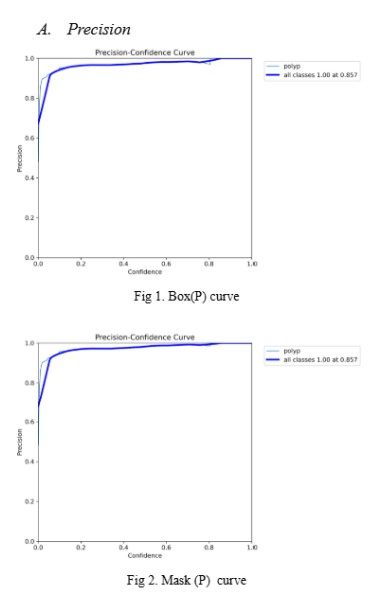

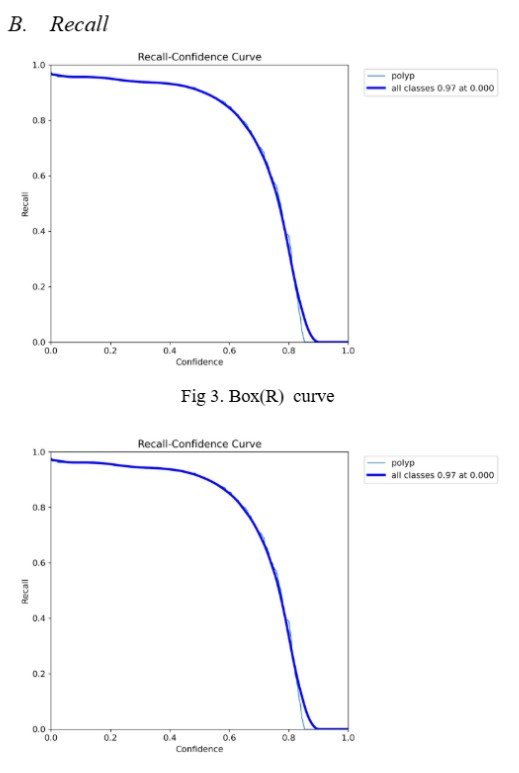

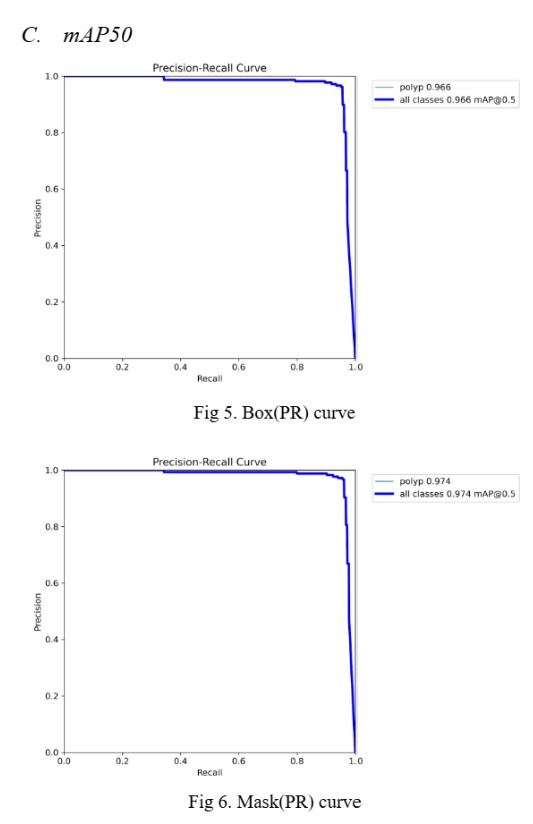

These results indicate that the model achieved excellent detection and segmentation accuracy, with high precision (few false positives) and high recall (few missed detections). The mAP@0.5–0.95 scores above 0.80 confirm consistent performance across multiple IoU thresholds.

### **Confusion Matrix Results**
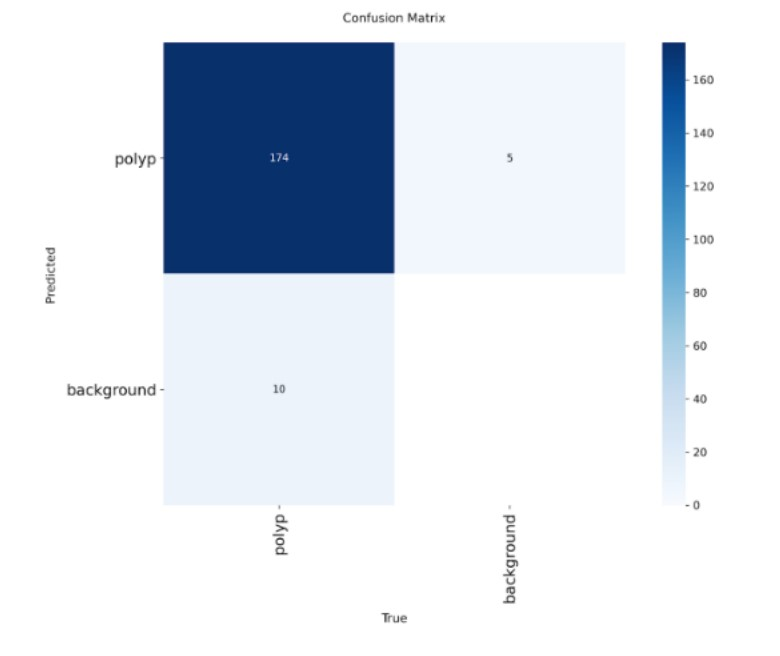
The unnormalized confusion matrix shows:
- 174 polyps correctly classified as polyps.  
- 10 missed polyps (false negatives).  
- 5 false positives from background misclassifications.  

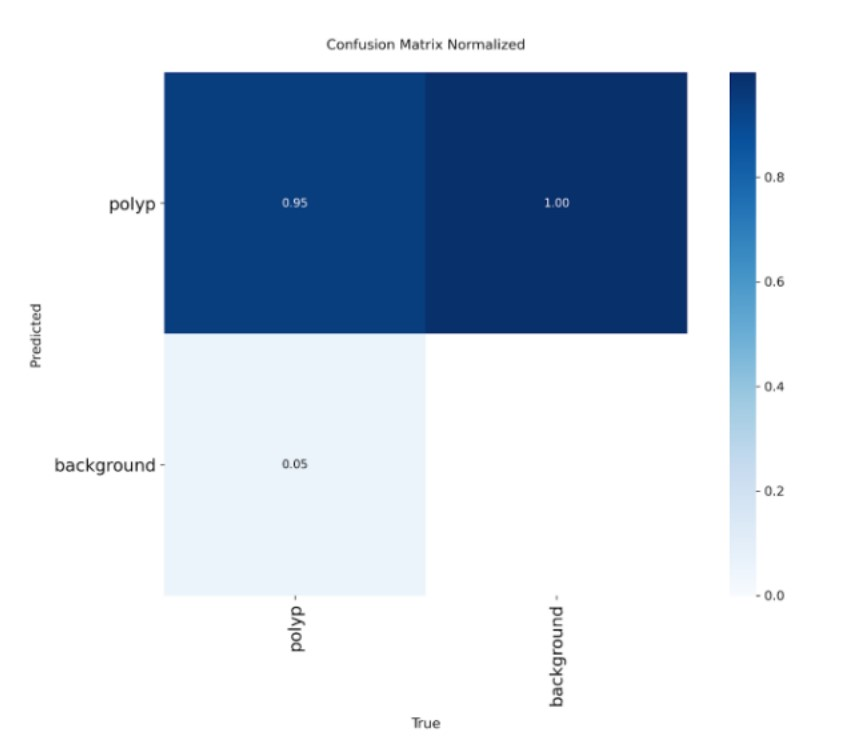
The normalized confusion matrix confirms that:
- 95% of actual polyps were correctly identified, and  
- Only 5% were missed, mainly due to small or low-contrast lesions.  

### **Efficiency and Speed**
The model achieved a GFLOPs value of 9.6, demonstrating an optimal balance between speed and accuracy.  
During testing:
- **Preprocessing:** 1.9 ms  
- **Inference:** 10.2 ms  
- **Postprocessing:** 3.5 ms  

This results in real-time segmentation capability, making it suitable for clinical applications.

### **Visual and Qualitative Results**
Test images confirmed that the model:
- Accurately localized polyps using bounding boxes and segmentation masks.  
- Maintained consistent segmentation quality even on unseen data.  
- Rarely produced false detections, highlighting its reliability and robustness.

### **Overall Findings**
The YOLOv11n-Seg model successfully learned to detect and segment polyps in pediatric colonoscopy images with near-perfect accuracy. Its lightweight architecture provided fast, precise, and efficient performance suitable for potential real-time diagnostic support. Minor misclassifications were linked to small or flat polyps, which could be mitigated through additional data augmentation and fine-tuning in future work.


In [ ]:
# --------------------------------------------------------------
# Save, Collect, and Zip Training Logs
# These logs will be used for visualization or documentation.
# --------------------------------------------------------------

import shutil
import os

# Source: YOLOv12 training run directory
src = "/content/runs/segment/yolov12_seg_rf_gpu"

# Destination: Local folder to store logs
dst = "/content/logs_for_visualization"

# Create destination folder if it doesn’t exist
os.makedirs(dst, exist_ok=True)

# Copy all files (metrics, results.csv, tensorboard logs, etc.)
shutil.copytree(src, dst, dirs_exist_ok=True)
print(f"✅ Logs copied to: {dst}")

# Zip the logs folder for easy download or sharing
shutil.make_archive("/content/yolov12_seg_logs", 'zip', dst)
print("✅ Logs zipped successfully at: /content/yolov12_seg_logs.zip")

# Optional: Display the zip file path for download
!ls -lh /content/yolov12_seg_logs.zip


✅ Logs copied to: /content/logs_for_visualization
✅ Logs zipped successfully at: /content/yolov12_seg_logs.zip
-rw-r--r-- 1 root root 17M Oct 26 16:12 /content/yolov12_seg_logs.zip


##**Section 8. Documentation (IEEE Format)**

Our final project paper follows the IEEE format and includes the following sections:

1. Abstract

2. Introduction

3. Methodology – dataset, model, training, and deployment

4. Results and Discussion

5. Conclusion and Future Work

6. References (IEEE style)

The complete paper is written and updated in Google Docs for collaboration and formatting.

Refer to the complete IEEE-format paper at the link below:

[IEEE Paper](https://docs.google.com/document/d/1IGrdhRclwxNmVgN3zz4L2NFOelPkw3qZBBGcRkuZJz8/edit?usp=sharing)

## **Section 9. Insights and Conclusions**

Through this project, the researchers gained a comprehensive understanding of the end-to-end process of developing a computer vision system, from data preparation and annotation to model training, evaluation, and fine-tuning. They discovered that dataset quality and organization play a critical role in achieving high performance, as even minor labeling errors can significantly impact accuracy. The study also deepened their knowledge of transfer learning, where pre-trained YOLO models were fine-tuned to perform instance segmentation efficiently. Additionally, the researchers learned how hyperparameters such as learning rate, batch size, and augmentation strategies affect model convergence, and how mean Average Precision (mAP) effectively quantifies a model’s ability to detect and segment objects.

### **Strengths**
- The YOLO-based model demonstrated **high accuracy and real-time inference capability**, successfully detecting and segmenting polyps in colonoscopy images.  
- The system proved to be **highly adaptable**, allowing easy retraining for other medical imaging or object segmentation tasks with minimal modification.

### **Limitations**
- Model training required **substantial computational resources**, making experimentation with larger architectures challenging on limited hardware.  
- Some **false negatives** occurred for small or low-contrast polyps, suggesting the need for further data refinement and augmentation.

### **Future Improvements**
- **Expand and diversify the dataset** to include more samples across different imaging conditions and patient demographics to improve robustness.  
- **Experiment with larger YOLO variants** or hybrid transformer-based models once more powerful GPU resources become available.  
- **Incorporate post-processing techniques** or ensemble models to further enhance detection consistency and reduce false positives.

---

Overall, the project provided valuable hands-on experience in applying deep learning techniques to medical image analysis. It strengthened the researchers’ understanding of how modern computer vision models can be tailored to healthcare applications and highlighted the importance of data quality, optimization, and continuous model improvement in achieving reliable AI-assisted diagnosis.


##**Section 10. References**
Comia, L. V. (2025). Fish Image Instance Segmentation Using the Separation of the Mask Produced for Fish Size Measurement. 2024 28th International Conference on Information Technology (IT), 1–5. https://doi.org/10.1109/it64745.2025.10930277

Comia, L. V., & Festijo, E. D. (2024a). Performance Analysis of Original     Implementation of ResNet50-Mask-RCNN using Transfer Learning: A Benchmark Data for Backbone-Improved Based Future Comparative Studies. 2024 28th International Conference on Information Technology (IT), 1–6. https://doi.org/10.1109/it61232.2024.10475763

Comia, L. V., & Festijo, E. D. (2024b). Attention Mechanism-Based Dense Upsampling of Transfer Learning Mask RCNN for Improved Object Segmentation. 2024 IEEE International Conference on Cybernetics and Innovations (ICCI), 1–6. https://doi.org/10.1109/icci60780.2024.10532656

